In [72]:
# 라이브러리 로드
# 필수 라이브러리 Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import platform
import json
from pprint import pprint

warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

# 데이터프레임 출력제한 해제
pd.set_option('display.max_rows', None)      # 행 제한 해제
pd.set_option('display.max_columns', None)   # 열 제한 해제
pd.set_option('display.max_colwidth', None)  # 셀 내용 제한 해제

---
### IT 기업 대상으로 통계 시작.

In [73]:
# IT 기업의 채널 데이터 로드
df_channel_IT = pd.read_csv('../../data/FOOD채널정보조회.csv', encoding='utf-8')

df_channel_IT.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        71 non-null     int64
 1   channel_id        71 non-null     str  
 2   title             71 non-null     str  
 3   description       56 non-null     str  
 4   subscriber_count  71 non-null     int64
 5   view_count        71 non-null     int64
 6   video_count       71 non-null     int64
 7   thumbnails        71 non-null     str  
 8   created_date      71 non-null     str  
dtypes: int64(4), str(5)
memory usage: 31.5 KB


In [74]:
df_channel_IT['Unnamed: 0']

0      0
1      1
2      2
3      3
4      4
5      5
6      6
7      7
8      8
9      9
10    10
11    11
12    12
13    13
14    14
15    15
16    16
17    17
18    18
19    19
20    20
21    21
22    22
23    23
24    24
25    25
26    26
27    27
28    28
29    29
30    30
31    31
32    32
33    33
34    34
35    35
36    36
37    37
38    38
39    39
40    40
41    41
42    42
43    43
44    44
45    45
46    46
47    47
48    48
49    49
50    50
51    51
52    52
53    53
54    54
55    55
56    56
57    57
58    58
59    59
60    60
61    61
62    62
63    63
64    64
65    65
66    66
67    67
68    68
69    69
70    70
Name: Unnamed: 0, dtype: int64

In [75]:
# 'Unnamed: 0' 컬럼 삭제
df_channel_IT_2 = df_channel_IT.drop(columns=['Unnamed: 0'])

df_channel_IT_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   channel_id        71 non-null     str  
 1   title             71 non-null     str  
 2   description       56 non-null     str  
 3   subscriber_count  71 non-null     int64
 4   view_count        71 non-null     int64
 5   video_count       71 non-null     int64
 6   thumbnails        71 non-null     str  
 7   created_date      71 non-null     str  
dtypes: int64(3), str(5)
memory usage: 31.0 KB


In [76]:
# Title이 Nan으로 채워진 데이터 삭제
df_channel_IT_2 = df_channel_IT_2[df_channel_IT_2['title'] != 'Nan'].reset_index().drop(columns=['index'])

df_channel_IT_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   channel_id        70 non-null     str  
 1   title             70 non-null     str  
 2   description       56 non-null     str  
 3   subscriber_count  70 non-null     int64
 4   view_count        70 non-null     int64
 5   video_count       70 non-null     int64
 6   thumbnails        70 non-null     str  
 7   created_date      70 non-null     str  
dtypes: int64(3), str(5)
memory usage: 30.8 KB


---
### 기초 통계량 확인

In [77]:
df_channel_IT_ststs = df_channel_IT_2.copy()

# 통계에 사용할 구독자 수, 조회수, 전체 영상 수, 채널 개설일 컬럼 선택
df_channel_IT_ststs = df_channel_IT_ststs.drop(columns=['title', 'description', 'thumbnails'])

df_channel_IT_ststs.info()

<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   channel_id        70 non-null     str  
 1   subscriber_count  70 non-null     int64
 2   view_count        70 non-null     int64
 3   video_count       70 non-null     int64
 4   created_date      70 non-null     str  
dtypes: int64(3), str(2)
memory usage: 6.0 KB


In [78]:
print(df_channel_IT_ststs['created_date'].iloc[0])

2012-06-05T11:33:04Z


In [79]:
import datetime

# 채널 생성일을 YYYY-mm-dd 형태로 통일
# format='ISO8601' : API 응답이 ISO8601 형태로 왔기 때문에, pandas에게 데이터 유형을 알려주는 역할 
# created_date에서 타임존(+00:00 부분) 정보 삭제하는 메서드 : .dt.tz_localize(None)
df_channel_IT_ststs['created_date'] = pd.to_datetime(df_channel_IT_ststs['created_date'], format='ISO8601').dt.tz_localize(None)

print(df_channel_IT_ststs['created_date'].iloc[0])

2012-06-05 11:33:04


In [80]:
# 채널이 생성된 연차 게산
# 🔴기준이 되는 날짜 삽입하면 됨 -> 우선은 데이터 수집 날짜로 설정
df_channel_IT_ststs['channel_age'] = datetime.datetime(2026,4,17).year - df_channel_IT_ststs['created_date'].dt.year

print(df_channel_IT_ststs['channel_age'].iloc[0])

14


In [81]:
# 채널 생성일 컬럼 문자열로 변경
# df_channel_IT_ststs['created_date'].dt.strftime('%Y-%m-%d')

### **데이터의 기초적인 분포 확인**

In [82]:
# 평균, 표준편차, 최솟값, 최댓값, 백분위값 확인
df_channel_IT_ststs[['view_count', 'subscriber_count', 'video_count', 'channel_age']].describe()

,view_count,subscriber_count,video_count,channel_age
count,7.000000e+01,7.000000e+01,70.000000,70.000000
mean,1.633228e+08,6.831300e+04,368.057143,10.228571
std,2.752718e+08,1.755401e+05,427.539976,4.387636
min,1.287000e+03,5.000000e+00,4.000000,1.000000
25%,1.523506e+06,9.515000e+02,93.250000,6.000000
50%,5.401634e+07,1.310000e+04,252.000000,11.000000
75%,2.260869e+08,7.527500e+04,500.000000,13.000000
max,1.306936e+09,1.060000e+06,2580.000000,19.000000


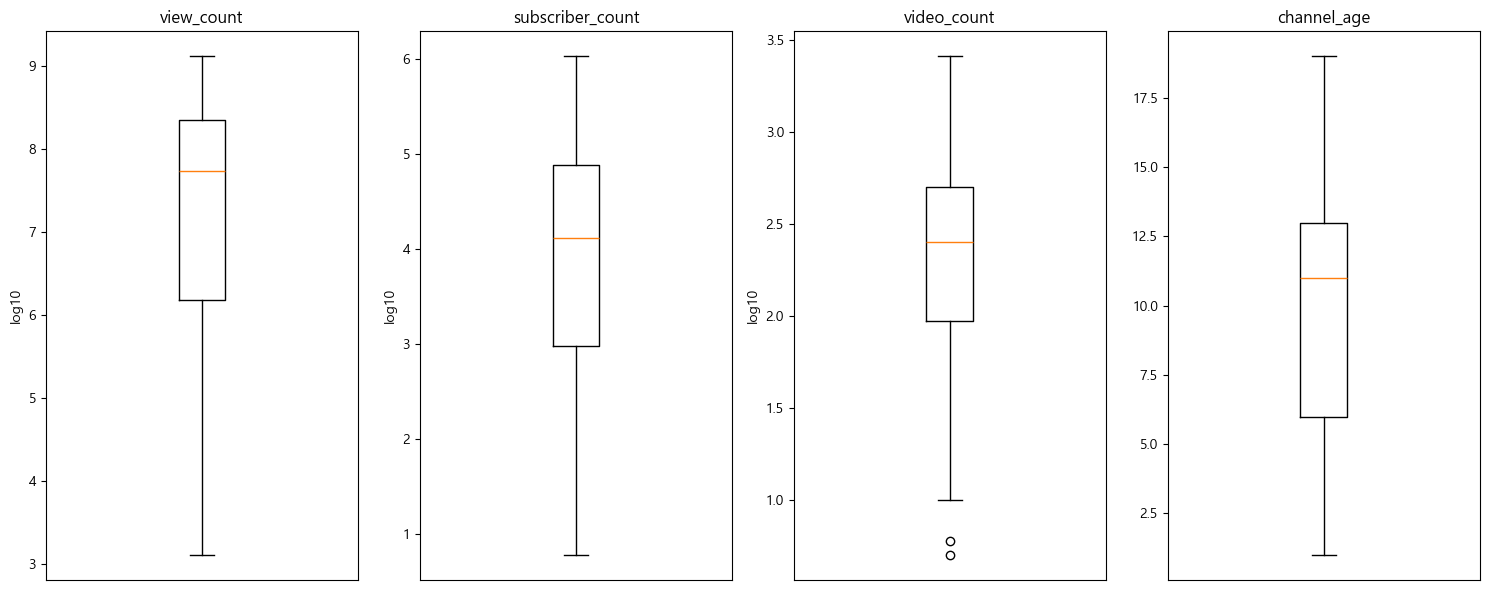

In [83]:
# 데이터 분포 확인 
# - view_count, subscriber_count, video_count
# - 극단값이 존재할 것으로 예상되어 로그 스케일로 변환하여 박스플롯으로 분포를 확인할 예정
# - 데이터에 log을 취할 때, 1을 더한 이유: 각 컬럼들의 평균/최솟값/최댓값을 확인했을 때, 최솟값이 0인 경우가 있었는데
#                                    수학적으로 log(0)은 존재하지 않기 때문에 에러가 생기지 않도록 1을 더한 것이다
#                                    숫자가 커질수록 +1의 영향은 매우 작기 때문에 가능하다.
fig, axes = plt.subplots(1, 4, figsize=(15, 6))

cols = ['view_count', 'subscriber_count', 'video_count']

for ax, col in zip(axes, cols): # zip()함수를 사용해서 인덱스 순서대로 axes[i]와 컬럼이 짝지어짐
    log_data_boxplot = np.log10(df_channel_IT_ststs[col] + 1) # 데이터에 로그를 취함
    ax.boxplot(log_data_boxplot)
    ax.set_title(col)
    ax.set_xticks([])       # x축 숫자 제거
    ax.set_ylabel('log10')  # y축 값이 log 10을 취한 값이라는 걸 나타내기 위해 추가

# channel_age - 스케일 변환 x
axes[3].boxplot(df_channel_IT_ststs['channel_age'])
axes[3].set_title('channel_age')
axes[3].set_xticks([])

plt.tight_layout()
plt.show()




# 숫자 단위 약어 해석
# K = 1,000
# M = 1,000,000 (백 만)
# B = 1,000,000,000 (십 억)

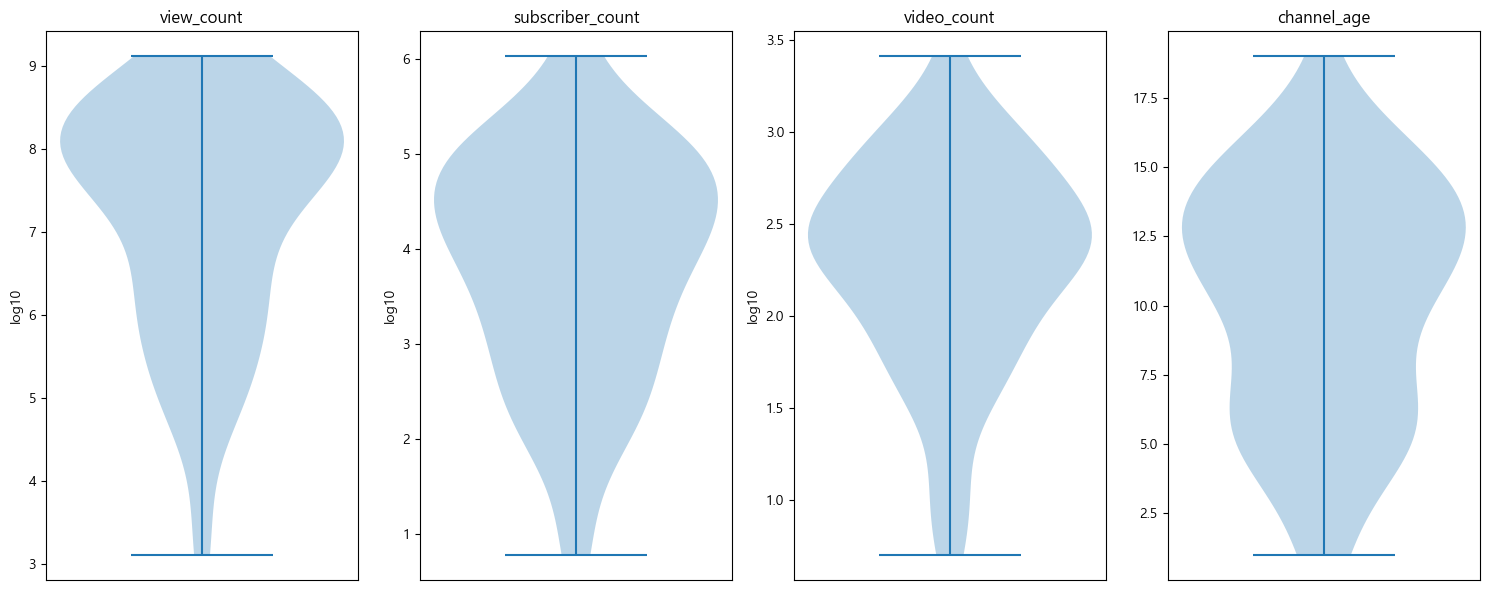

In [84]:
# 바이올린 플롯으로도 확인
fig, axes = plt.subplots(1, 4, figsize=(15, 6))

cols = ['view_count', 'subscriber_count', 'video_count']

for ax, col in zip(axes, cols):
    log_data_violinplot = np.log10(df_channel_IT_ststs[col] + 1)
    ax.violinplot(log_data_violinplot)
    ax.set_title(col)
    ax.set_xticks([])
    ax.set_ylabel('log10')

# channel_age - 스케일 변환 x
axes[3].violinplot(df_channel_IT_ststs['channel_age'])
axes[3].set_title('channel_age')
axes[3].set_xticks([])

plt.tight_layout()
plt.show()

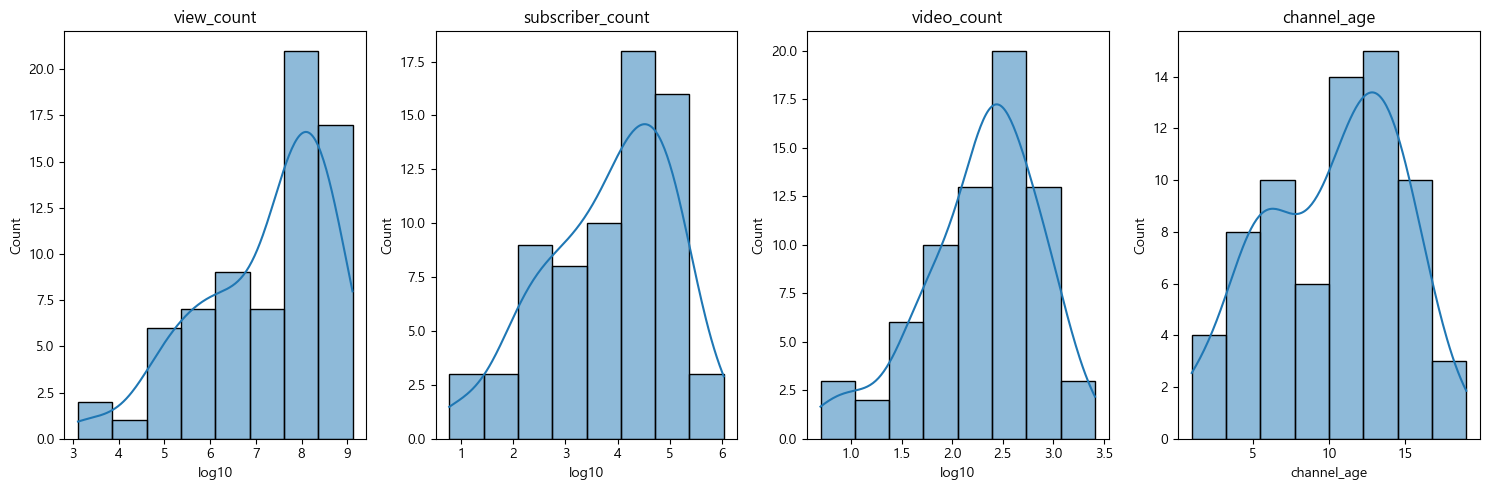

In [85]:
# 히스토그램과 KDE 곡선으로도 확인
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

cols = ['view_count', 'subscriber_count', 'video_count']

for ax, col in zip(axes, cols):
    log_data_hist = np.log10(df_channel_IT_ststs[col] + 1)
    sns.histplot(log_data_hist, kde=True, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('log10')
    
sns.histplot(df_channel_IT_ststs['channel_age'], kde=True, ax=axes[3])
axes[3].set_title('channel_age')

plt.tight_layout()
plt.show()

---
### channel_age별 조회수, 구독자수, 비디오 개수 분포 확인하기

In [86]:
# 채널 연차별 기초 통계량
df_channel_IT_ststs.groupby('channel_age')[['view_count', 'subscriber_count', 'video_count']].describe()

view_count                                            \
                 count          mean           std           min   
channel_age                                                        
1                  3.0  5.052292e+06  8.686477e+06  3.857000e+03   
3                  1.0  4.739494e+06           NaN  4.739494e+06   
4                  4.0  1.162760e+08  1.565688e+08  1.394825e+06   
5                  4.0  1.770083e+07  3.506127e+07  1.287000e+03   
6                  7.0  2.158563e+07  3.283148e+07  3.036800e+04   
7                  3.0  3.588347e+07  6.052876e+07  3.569800e+05   
8                  2.0  7.309064e+06  5.349825e+06  3.526167e+06   
9                  4.0  6.255989e+07  5.623624e+07  9.859860e+05   
10                 3.0  1.264274e+07  1.517234e+07  6.186010e+05   
11                 8.0  5.302196e+07  1.139100e+08  2.695750e+05   
12                 3.0  1.485384e+08  8.985200e+07  5.767184e+07   
13                11.0  2.785697e+08  2.951708e+08  5.508500e+04   
14                 4.0  1.886115e+08  1.311257e+08  1.331750e+05   
15                 7.0  3.417839e+08  2.860992e+08  3.492080e+07   
16                 3.0  1.959943e+08  1.119735e+08  9.856933e+07   
17                 2.0  1.293906e+09  1.842727e+07  1.280876e+09   
19                 1.0  5.846818e+07           NaN  5.846818e+07   

                                                                     \
                      25%           50%           75%           max   
channel_age                                                           
1            3.718900e+04  7.052100e+04  7.576510e+06  1.508250e+07   
3            4.739494e+06  4.739494e+06  4.739494e+06  4.739494e+06   
4            3.570463e+07  5.822048e+07  1.387918e+08  3.472680e+08   
5            6.241500e+04  2.550225e+05  1.789344e+07  7.029200e+07   
6            1.699815e+05  5.730238e+06  3.473578e+07  7.552726e+07   
7            9.387865e+05  1.520593e+06  5.364671e+07  1.057728e+08   
8            5.417616e+06  7.309064e+06  9.200513e+06  1.109196e+07   
9            4.007287e+07  5.595479e+07  7.844182e+07  1.373440e+08   
10           4.119343e+06  7.620085e+06  1.865481e+07  2.968953e+07   
11           9.814220e+05  3.164731e+06  3.629923e+07  3.307117e+08   
12           1.041375e+08  1.506031e+08  1.939717e+08  2.373403e+08   
13           3.406937e+07  2.692973e+08  3.631118e+08  9.133181e+08   
14           1.670640e+08  2.249604e+08  2.465080e+08  3.043919e+08   
15           1.016166e+08  2.819898e+08  5.573818e+08  7.575799e+08   
16           1.348300e+08  1.710907e+08  2.447069e+08  3.183230e+08   
17           1.287391e+09  1.293906e+09  1.300421e+09  1.306936e+09   
19           5.846818e+07  5.846818e+07  5.846818e+07  5.846818e+07   

            subscriber_count                                          \
                       count           mean            std       min   
channel_age                                                            
1                        3.0   41676.000000   72160.701188       6.0   
3                        1.0     113.000000            NaN     113.0   
4                        4.0   30732.750000   58190.310278     411.0   
5                        4.0   25874.500000   51417.153004       5.0   
6                        7.0   25313.142857   52471.016785     130.0   
7                        3.0    2150.000000    1186.970935    1430.0   
8                        2.0     481.500000     440.527525     170.0   
9                        4.0   27537.500000   37837.537248    2120.0   
10                       3.0    6792.333333    7079.782224     397.0   
11                       8.0   10098.000000   11112.712630     159.0   
12                       3.0   41966.666667   35784.400698   18000.0   
13                      11.0   44114.000000   50908.101461      66.0   
14                       4.0  515567.500000  554870.272128      70.0   
15                       7.0  129414.285714  167320.714284   11600.0   
16    

In [87]:
# 숫자값만 바꾸면 해당 연차의 채널 확인 가능
df_channel_IT_ststs[df_channel_IT_ststs['channel_age'] == 3]

,channel_id,subscriber_count,view_count,video_count,created_date,channel_age
62,UCr0W7lsBivPQN5mB2_IntCg,113,4739494,33,2023-08-28 06:28:51.294443,3


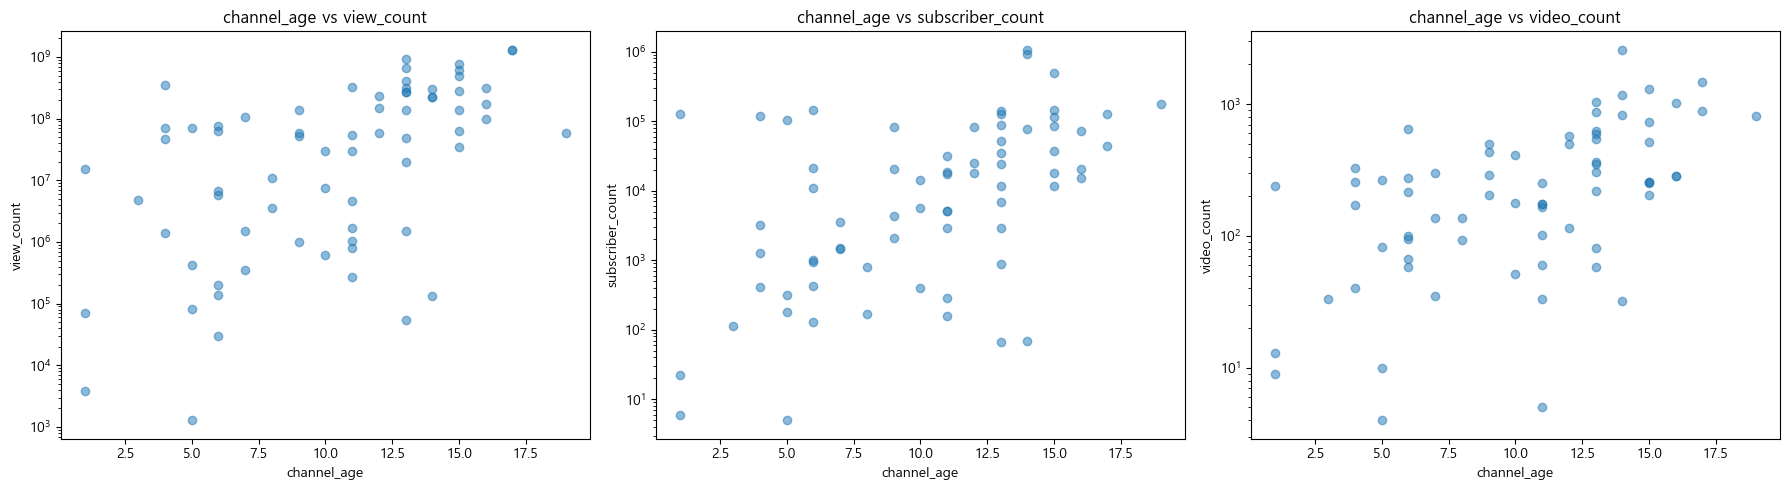

In [88]:
# 채널 연차별 산점도
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cols = ['view_count', 'subscriber_count', 'video_count']

for ax, col in zip(axes, cols):
    ax.scatter(df_channel_IT_ststs['channel_age'], df_channel_IT_ststs[col], alpha=0.5)
    ax.set_yscale('log') # y축을 로그 스케일로 변경
    ax.set_xlabel('channel_age')
    ax.set_ylabel(col)
    ax.set_title(f'channel_age vs {col}')

plt.tight_layout()
plt.show()

---
### 주어진 데이터를 활용한 파생 지표 계산해보기 
- 구독자 대비 조회수 비율 = 조회수 / 구독자 수
- 채널의 평균 업로드 주기 = 채널 운영 기간(일) / 영상수
- 운영기간동안 하루마다 평균적으로 몇 명의 구독자가 발생하였는가? = 구독자 수 / 채널 운영 기간(일)

In [89]:
# 전체 운영 기간(일)
# 🔴운영기간(일) 계산 기준은 데이터 수집이 완료된 2026/04/17으로 잡았으나, 추후 협의를 통해 변경 필요

df_channel_IT_ststs['total_operate_days'] = (
    datetime.datetime(2026,4,17) - df_channel_IT_ststs['created_date']
).dt.days

print(df_channel_IT_ststs['total_operate_days'].iloc[0])

5063


In [90]:
# 구독자 대비 조회수 비율 = 조회수 / 구독자 수
df_channel_IT_ststs['view_to_subs_ratio'] = (
    df_channel_IT_ststs['view_count'] / df_channel_IT_ststs['subscriber_count']
)

print(df_channel_IT_ststs['view_to_subs_ratio'].iloc[0])

328.71700323974085


In [91]:
# 채널의 평균 업로드 주기 = 채널 운영 기간(일) / 영상수
df_channel_IT_ststs['avg_upload_cycle'] = (
    df_channel_IT_ststs['total_operate_days'] / df_channel_IT_ststs['video_count']
)

print(df_channel_IT_ststs['avg_upload_cycle'].iloc[0])

4.316283034953112


In [92]:
# 운영기간동안 하루마다 평균적으로 몇 명의 구독자가 발생하였는가? = 구독자 수 / 채널 운영 기간(일)
df_channel_IT_ststs['daily_subs_growth'] = (
    df_channel_IT_ststs['subscriber_count'] / df_channel_IT_ststs['total_operate_days']
)

print(df_channel_IT_ststs['daily_subs_growth'].iloc[0])

182.8955164921983


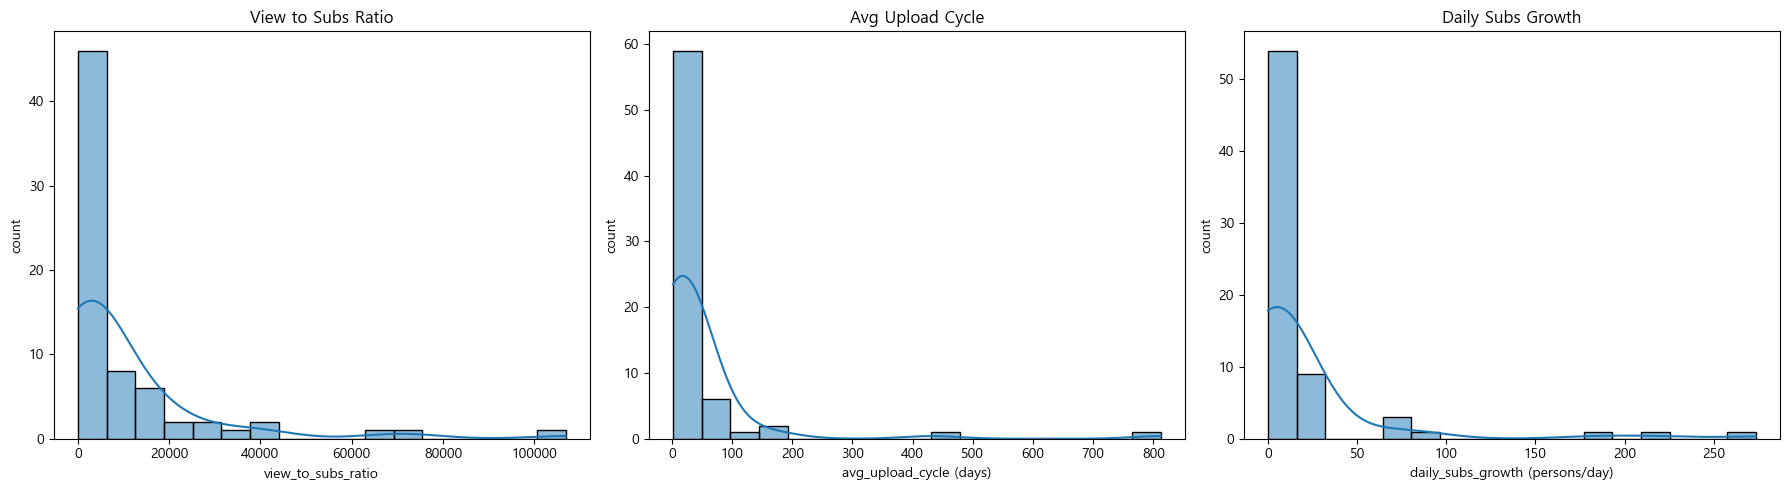

In [93]:
# 3가지 파생 지표의 시각화 (히스토그램+KDE 곡선)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. 구독자 대비 조회수 비율
axes[0].set_title('View to Subs Ratio')
sns.histplot(df_channel_IT_ststs['view_to_subs_ratio'], 
            kde=True, ax=axes[0])
axes[0].set_xlabel('view_to_subs_ratio')
axes[0].set_ylabel('count')

# 2. 평균 업로드 주기
axes[1].set_title('Avg Upload Cycle')
sns.histplot(df_channel_IT_ststs['avg_upload_cycle'], 
            kde=True, ax=axes[1])
axes[1].set_xlabel('avg_upload_cycle (days)')
axes[1].set_ylabel('count')

# 3. 하루 평균 구독자 증가 수
axes[2].set_title('Daily Subs Growth')
sns.histplot(df_channel_IT_ststs['daily_subs_growth'], 
            kde=True, ax=axes[2])
axes[2].set_xlabel('daily_subs_growth (persons/day)')
axes[2].set_ylabel('count')

plt.tight_layout()
plt.show()

In [94]:
df_channel_IT_ststs[
    ['view_to_subs_ratio', 'avg_upload_cycle', 'daily_subs_growth']
].describe()

,view_to_subs_ratio,avg_upload_cycle,daily_subs_growth
count,70.000000,70.000000,70.000000
mean,10155.506287,42.549698,19.424205
std,18589.573402,110.041570,48.062968
min,25.808526,1.883333,0.002899
25%,480.856468,7.542137,0.451868
50%,2918.941157,17.770824,2.987265
75%,11466.227896,29.496834,14.695128
max,106851.699385,812.000000,273.522976
